In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carrega e prepara os dados
data = pd.read_csv("../../Data.csv")
data = data.drop(columns=["VD", "VE", "tempo"])
data.index = (np.arange(0, len(data), 1).astype(float) * 0.07).round(5)

data = data.rename(columns={
    "Setpoint VD": "Wd",
    "Setpoint VE": "We",
    "Theta": "theta(Wd,We)",
    "X": "x(Wd,We)",
    "Y": "y(Wd,We)",
})

In [2]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler

PREDICTORS = ["Wd", "We"]
TARGET = ["theta(Wd,We)"]

def PlotTimeSeries(df, img_name="data.svg", PlotOut=True):    
    # Estilo Seaborn
    sns.set_theme(style="whitegrid")

    # Criando a figura
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plotando Wd e We como linhas
    for preds in PREDICTORS:
        sns.lineplot(x=df.index, y=df[preds], ax=ax1, marker="o", label=preds,  linewidth=2)

    if PlotOut:
        ax2 = ax1.twinx()
        for target in TARGET:
            sns.lineplot(x=df.index, y=df[target], ax=ax2, marker="o", label=target, linestyle="dashed", linewidth=2, color="red")
            ax2.set_ylabel("Posição Angular", fontsize=12, color="gray")

    # Ajustando os rótulos dos eixos
    ax1.set_xlabel("Tempo (s) - Período de amostragem (T=0.07 s)", fontsize=12)
    ax1.set_ylabel("Velocidade Angular", fontsize=12, color="black")

    # Adicionando legendas
    ax1.legend(loc="upper left")
    if PlotOut:
        ax2.legend(loc="upper right")

    # Título
    plt.title("Posição angular em função da velocidade nas rodas", fontsize=14)

    # Exibindo o gráfico
    plt.show()

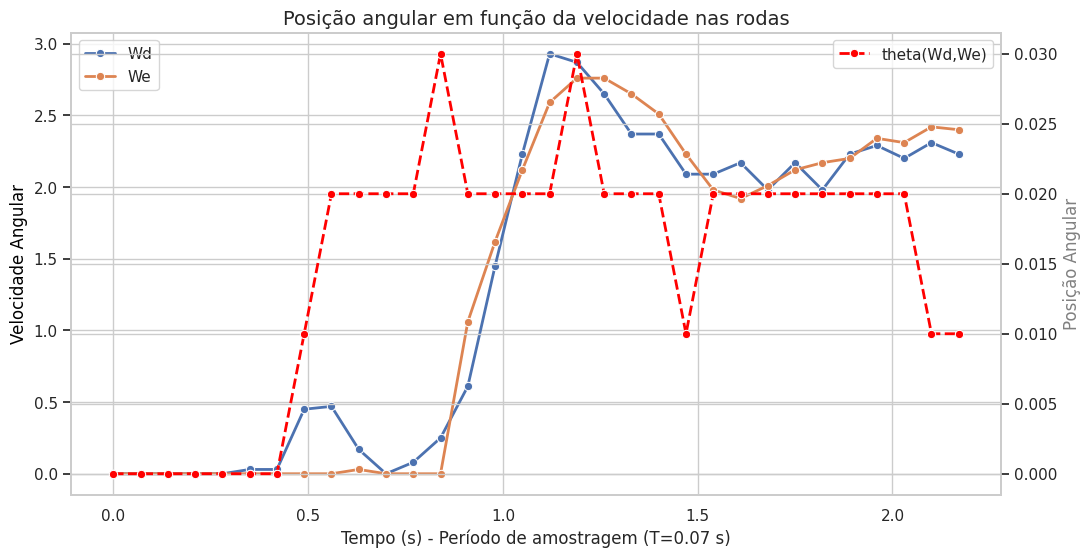

In [3]:
PlotTimeSeries(data.head(32))

In [4]:
PREDICTORS = ["Wd", "We"]
TARGET = "theta(Wd,We)"

def get_XY(data, time_steps, units, output_dim):
    total_samples = (len(data) - time_steps) // time_steps

    X = []
    Y = []
    
    for i in range(total_samples):
        start_idx = i * time_steps
        end_idx = start_idx + time_steps

        X_seq = data.iloc[start_idx:end_idx][PREDICTORS].values  # shape: (time_steps, features)
        Y_target = data.iloc[end_idx][TARGET]  # escalar

        X.append(X_seq)
        Y.append(Y_target)

    X = np.array(X)  # shape: (batch, time_steps, features)
    Y =  Y = np.array(Y).reshape(-1, 1).repeat(output_dim, axis=1)  # shape (batch, output_dim)
    h0 = np.full((X.shape[0], units), fill_value=Y[0]) # shape (batch, units)

    print(f"Shape X (batch, time_steps, features): {X.shape}")
    print(f"Shape Y (batch, output_dim): {Y.shape}")
    print(f"Shape h0 (batch, units): {h0.shape}")
    
    return X, Y, h0

In [5]:
def PlotOut(valuer):
    sns.set_theme(style="whitegrid")

    fig, axs = plt.subplots(3, 1, figsize=(12, 12), sharey=False)

    datasets = [
        ('Treinamento', valuer.train_samples_y, valuer.train_pred),
        ('Validação', valuer.val_samples_y, valuer.val_pred),
        ('Teste', valuer.test_samples_y, valuer.test_pred)
    ]

    times = [
        np.arange(len(valuer.train_samples_y)),
        np.arange(len(valuer.val_samples_y)),
        np.arange(len(valuer.test_samples_y))
    ]

    for i, (title, y_true, y_pred) in enumerate(datasets):
        # Garante que são vetores 1D
        y_true = np.ravel(y_true)
        y_pred = np.ravel(y_pred)

        sns.lineplot(x=times[i], y=y_true, ax=axs[i], marker="o", label="Amostras Reais", linewidth=2)
        sns.lineplot(x=times[i], y=y_pred, ax=axs[i], marker="o", label="Valores preditos", linewidth=2)

        axs[i].set_title(f'{title}')
        axs[i].set_xlabel('Tempo')
        axs[i].set_ylabel('Valor')
        axs[i].legend()
        axs[i].grid(True)

    plt.suptitle('Comparação temporal: Predição (curva) vs Amostras Reais (pontos)')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()  
    
    path = f"./content/models/{valuer.fileName}.png"
    fig.savefig(path)    

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 
from keras import layers, models, regularizers, initializers, optimizers
from keras.callbacks import EarlyStopping
from itertools import product


class EvalRNN:
    
    def __init__(self, dataset, epochs, time_steps, act_h, act_o):
        self.epochs = epochs
        self.Dataset = dataset
        self.output_dim = np.size(TARGET)
        self.time_steps = time_steps
        self.act_h = act_h
        self.act_o = act_o
        self.better_metrics = {}


    def SplitData(self, units):
        self.units = units
                
        train_data, test_data = train_test_split(self.Dataset, test_size=0.25, shuffle=False)
        train_data, val_data = train_test_split(train_data, test_size=0.15, shuffle=False)
                
        self.train_samples_x, self.train_samples_y, self.h0_train = get_XY(train_data, self.time_steps, units, self.output_dim)       
        self.val_samples_x, self.val_samples_y, self.h0_val = get_XY(val_data, self.time_steps, units, self.output_dim)
        self.test_samples_x, self.test_samples_y, self.h0_test = get_XY(test_data, self.time_steps, units, self.output_dim)

        self.time_steps = self.train_samples_x.shape[1]
        self.features = self.train_samples_x.shape[2]
        
    def BuildModel(self, hidden_sizes, param_reg):
        initializer = initializers.RandomUniform(minval=-0.5,
                                                maxval=0.5,
                                                # seed=np.random.randint(1, 10000)
                                                )
        regularizer = regularizers.L2(param_reg)
        inputs = layers.Input((self.time_steps, self.features))
        initial_state = layers.Input((self.units,))

        # Primeira camada RNN com estado inicial
        rnn_layer = layers.SimpleRNN(
            hidden_sizes[0],
            activation=self.act_h,
            kernel_regularizer=regularizer,
            kernel_initializer=initializer,
            return_sequences=(len(hidden_sizes) > 1)  
        )(inputs, initial_state=initial_state)

        # Demais camadas RNN
        for size in hidden_sizes[1:-1]:
            rnn_layer = layers.SimpleRNN(
                size,
                activation=self.act_h,
                kernel_regularizer=regularizer,
                kernel_initializer=initializer,
                return_sequences=True 
            )(rnn_layer)

        # Última camada RNN
        if len(hidden_sizes) > 1:
            rnn_layer = layers.SimpleRNN(
                hidden_sizes[-1],
                activation=self.act_h,
                kernel_regularizer=regularizer,
                kernel_initializer=initializer,
                return_sequences=False  
            )(rnn_layer)
       
       # Output mlp layer
        output = layers.Dense(self.output_dim,
                            activation=self.act_o,
                            kernel_regularizer=regularizer,
                            kernel_initializer=initializer)(rnn_layer)
        
        model = models.Model([inputs] + [initial_state], output)
        return(model)
    
    def CompileModel(self, model, lr):
        model.compile(loss="mse", optimizer=optimizers.Adam(learning_rate=lr))
        early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

        model.fit(
            [self.train_samples_x, self.h0_train],
            self.train_samples_y,
            epochs=self.epochs,
            validation_data=([self.val_samples_x, self.h0_val], self.val_samples_y),
            callbacks=[early_stop],
            verbose=False,
            shuffle=False   
        )
    
    def ComputeMetrics(self, model):
        self.train_pred = np.squeeze(model.predict([self.train_samples_x, self.h0_train]))
        self.val_pred = np.squeeze(model.predict([self.val_samples_x, self.h0_val]))
        self.test_pred = np.squeeze(model.predict([self.test_samples_x, self.h0_test]))


        return ({
                    'r2_training': r2_score(self.train_samples_y, self.train_pred),
                    'mse_training': mean_squared_error(self.train_samples_y, self.train_pred),
                    'mape_training': mean_absolute_percentage_error(self.train_samples_y, self.train_pred),
                    'rmse_training': root_mean_squared_error(self.train_samples_y, self.train_pred),

                    'r2_test': r2_score(self.test_samples_y, self.test_pred),
                    'mse_test': mean_squared_error(self.test_samples_y, self.test_pred),
                    'mape_test': mean_absolute_percentage_error(self.test_samples_y, self.test_pred),
                    'rmse_test': root_mean_squared_error(self.test_samples_y, self.test_pred),
                    
                    'r2_val': r2_score(self.val_samples_y, self.val_pred),
                    'mse_val': mean_squared_error(self.val_samples_y, self.val_pred),
                    'mape_val': mean_absolute_percentage_error(self.val_samples_y, self.val_pred),
                    'rmse_val': root_mean_squared_error(self.val_samples_y, self.val_pred),
            })

    def SaveModelWeights(self, model):
        path = f"./content/models/{self.fileName}.weights.h5"
        open(path,'w').close()
        model.save_weights(path) 

    def LoopWeights(self, model, run_times, lr, boundarie, sort_by, idx):
        better_model = 0
        save = False

        for i in range(run_times):
            print (f"+++++++++++ [{idx}] | {i + 1} ++++++++++++++++++")
            self.CompileModel(model, lr)
            metrics = self.ComputeMetrics(model)
            
            if (metrics[sort_by] >= boundarie): # should be >= to acsending metrics
                self.fileName = f"model_{idx}_{better_model}"
                self.SaveModelWeights(model)
                self.better_metrics[self.fileName] = metrics
                better_model += 1
                save = True
        return(save)

    def Evaluate(self, hidden_sizes, regularizers, learning_rate, run_times, boundarie, sort_by):
        for count, (hidden_size, reg, lr) in enumerate(product(hidden_sizes, regularizers, learning_rate), start=1):
            header =  f"Hidden Size={hidden_size}, regularizer={reg}, learning_rate={lr}"
            print(f"Testando combinacao{count}: {header}")
            
            self.SplitData(units=hidden_size[0])        
            model = self.BuildModel(hidden_size, reg)
            
            if (self.LoopWeights(model, run_times, lr, boundarie, sort_by, f"{count}") == True):        
                self.DisplayBetterResults(header, sort_by, f"{count}")
                PlotOut(self)
                
        self.better_metrics = {}
  
                
    def DisplayBetterResults(self, header, sort_by, dataset=0):
        df = pd.DataFrame.from_dict(self.better_metrics, orient='index')
        df = df.sort_values([sort_by])
        display(df)
        path = f'./content/results/metrics_{dataset}'
        df.to_excel(f"{path}.xlsx", index=True)
        print(f"DataFrame salvo em {path}")
        with open(f"{path}.txt", 'w') as arquivo:
            arquivo.write(header)            
       

2025-05-11 17:09:00.322050: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-11 17:09:00.328477: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-11 17:09:00.349723: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746983340.380948  244331 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746983340.391327  244331 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746983340.414871  244331 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [ ]:
Valuer = EvalRNN(dataset = data,
                epochs = 1000,
                time_steps = 2,
                act_h = 'tanh',
                act_o = 'sigmoid',
                )        

: 

Testando combinacao1: Hidden Size=[2], regularizer=0.02, learning_rate=0.01
Shape X (batch, time_steps, features): (682, 2, 2)
Shape Y (batch, output_dim): (682, 1)
Shape h0 (batch, units): (682, 2)
Shape X (batch, time_steps, features): (120, 2, 2)
Shape Y (batch, output_dim): (120, 1)
Shape h0 (batch, units): (120, 2)
Shape X (batch, time_steps, features): (267, 2, 2)
Shape Y (batch, output_dim): (267, 1)
Shape h0 (batch, units): (267, 2)
+++++++++++ [1] | 1 ++++++++++++++++++


2025-05-11 17:09:06.039386: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
+++++++++++ [1] | 2 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
+++++++++++ [1] | 3 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
+++++++++++ [1] | 4 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
+++++++++++ [1] | 5 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
+++++++++++ [1] | 6 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
+++++++++++ [1] | 7 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/ste

,r2_training,mse_training,mape_training,rmse_training,r2_test,mse_test,mape_test,rmse_test,r2_val,mse_val,mape_val,rmse_val
model_1_0,0.503825,0.070633,6.597657e+13,0.265769,-33.961213,0.761627,1.456831,0.872713,-229.280094,0.041027,1.295043e+14,0.202550
model_1_1,0.507259,0.070145,6.358627e+13,0.264848,-31.759743,0.713668,1.409604,0.844789,-219.959117,0.039366,1.239616e+14,0.198409
model_1_9,0.509655,0.069804,5.692521e+13,0.264204,-30.144361,0.678477,1.371760,0.823697,-189.674343,0.033970,1.094929e+14,0.184311
model_1_2,0.509686,0.069799,6.184491e+13,0.264195,-31.650071,0.711279,1.406423,0.843374,-212.189589,0.037982,1.202101e+14,0.194889
model_1_8,0.510028,0.069750,5.732037e+13,0.264103,-30.295248,0.681764,1.375231,0.825690,-191.046459,0.034215,1.104049e+14,0.184973
model_1_7,0.510343,0.069706,5.776221e+13,0.264018,-30.493202,0.686077,1.379756,0.828298,-192.721926,0.034513,1.114215e+14,0.185778
model_1_3,0.510633,0.069664,6.063480e+13,0.263940,-31.359019,0.704939,1.399650,0.839606,-206.390172,0.036949,1.176123e+14,0.192220
model_1_6,0.510694,0.069656,5.832013e+13,0.263924,-30.656371,0.689631,1.383495,0.830441,-195.456905,0.035001,1.126227e+14,0.187085
model_1_5,0.510905,0.069626,5.894889e+13,0.263866,-30.868753,0.694258,1.388364,0.833222,-198.310300,0.035509,1.139923e+14,0.188438
model_1_4,0.510940,0.069621,5.970194e+13,0.263857,-31.103858,0.699380,1.393759,0.836289,-201.873866,0.036144,1.156152e+14,0.190116


DataFrame salvo em ./content/results/metrics_1


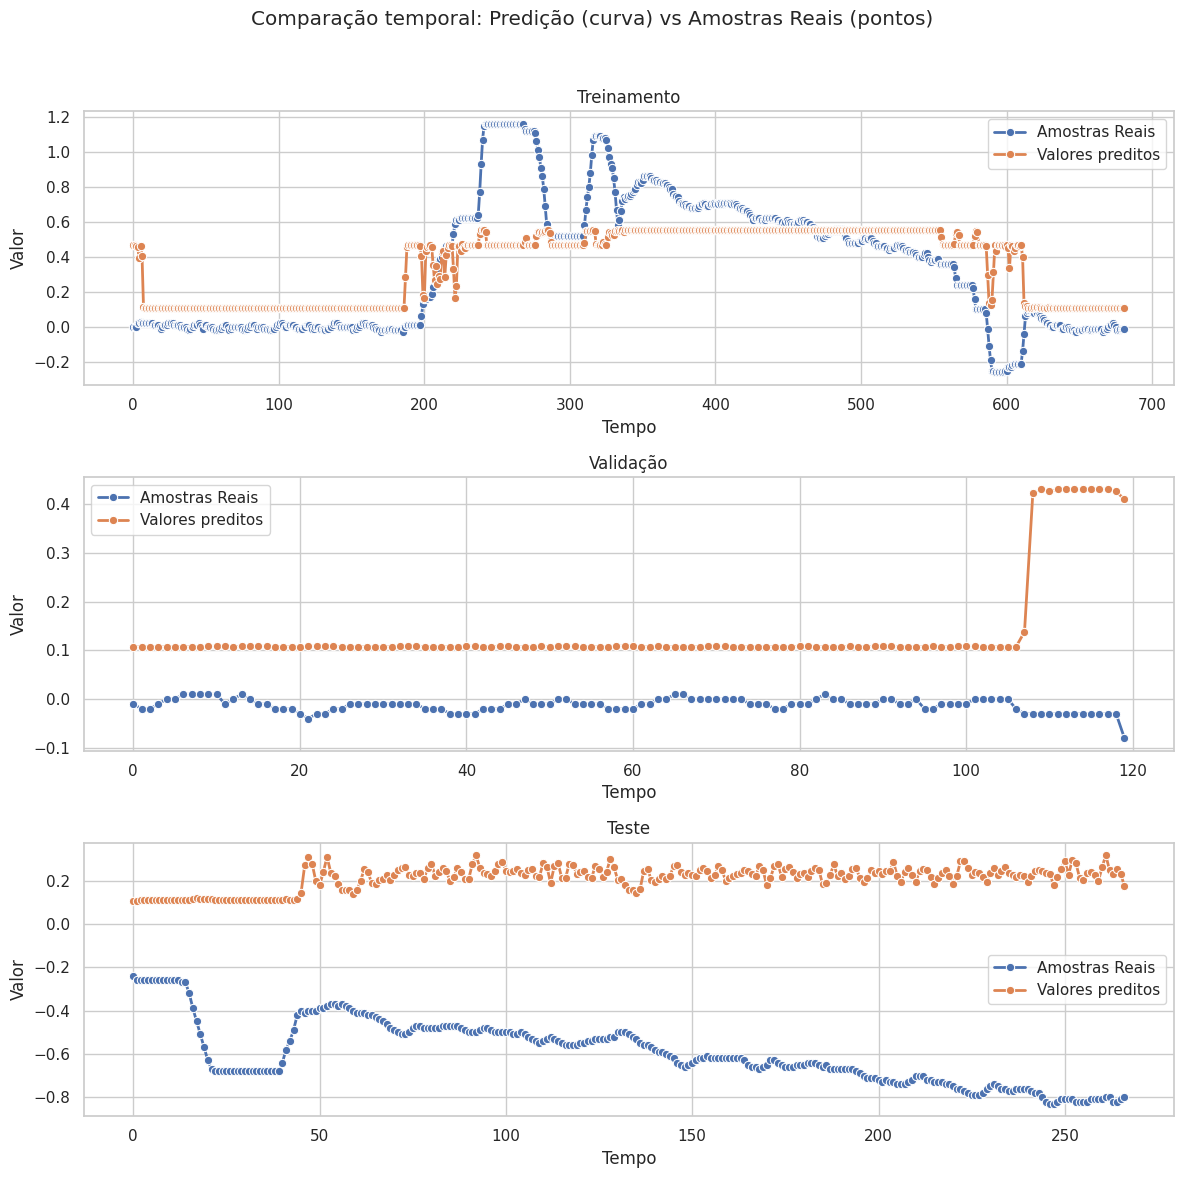

Testando combinacao2: Hidden Size=[2], regularizer=0.02, learning_rate=0.1
Shape X (batch, time_steps, features): (682, 2, 2)
Shape Y (batch, output_dim): (682, 1)
Shape h0 (batch, units): (682, 2)
Shape X (batch, time_steps, features): (120, 2, 2)
Shape Y (batch, output_dim): (120, 1)
Shape h0 (batch, units): (120, 2)
Shape X (batch, time_steps, features): (267, 2, 2)
Shape Y (batch, output_dim): (267, 1)
Shape h0 (batch, units): (267, 2)
+++++++++++ [2] | 1 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
+++++++++++ [2] | 2 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
+++++++++++ [2] | 3 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
+++++++++++ [2] | 4 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
4/4 ━━━━━━━━━━━

,r2_training,mse_training,mape_training,rmse_training,r2_test,mse_test,mape_test,rmse_test,r2_val,mse_val,mape_val,rmse_val
model_2_1,0.501377,0.070982,6.426358e+13,0.266424,-56.801389,1.259199,1.879290,1.122140,-261.207306,0.046715,1.223655e+14,0.216136
model_1_0,0.503825,0.070633,6.597657e+13,0.265769,-33.961213,0.761627,1.456831,0.872713,-229.280094,0.041027,1.295043e+14,0.202550
model_2_0,0.504834,0.070490,5.046211e+13,0.265499,-59.235709,1.312230,1.973169,1.145526,-231.846950,0.041484,8.753646e+13,0.203676
model_1_1,0.507259,0.070145,6.358627e+13,0.264848,-31.759743,0.713668,1.409604,0.844789,-219.959117,0.039366,1.239616e+14,0.198409
model_1_9,0.509655,0.069804,5.692521e+13,0.264204,-30.144361,0.678477,1.371760,0.823697,-189.674343,0.033970,1.094929e+14,0.184311
model_1_2,0.509686,0.069799,6.184491e+13,0.264195,-31.650071,0.711279,1.406423,0.843374,-212.189589,0.037982,1.202101e+14,0.194889
model_1_8,0.510028,0.069750,5.732037e+13,0.264103,-30.295248,0.681764,1.375231,0.825690,-191.046459,0.034215,1.104049e+14,0.184973
model_1_7,0.510343,0.069706,5.776221e+13,0.264018,-30.493202,0.686077,1.379756,0.828298,-192.721926,0.034513,1.114215e+14,0.185778
model_1_3,0.510633,0.069664,6.063480e+13,0.263940,-31.359019,0.704939,1.399650,0.839606,-206.390172,0.036949,1.176123e+14,0.192220
model_1_6,0.510694,0.069656,5.832013e+13,0.263924,-30.656371,0.689631,1.383495,0.830441,-195.456905,0.035001,1.126227e+14,0.187085


DataFrame salvo em ./content/results/metrics_2


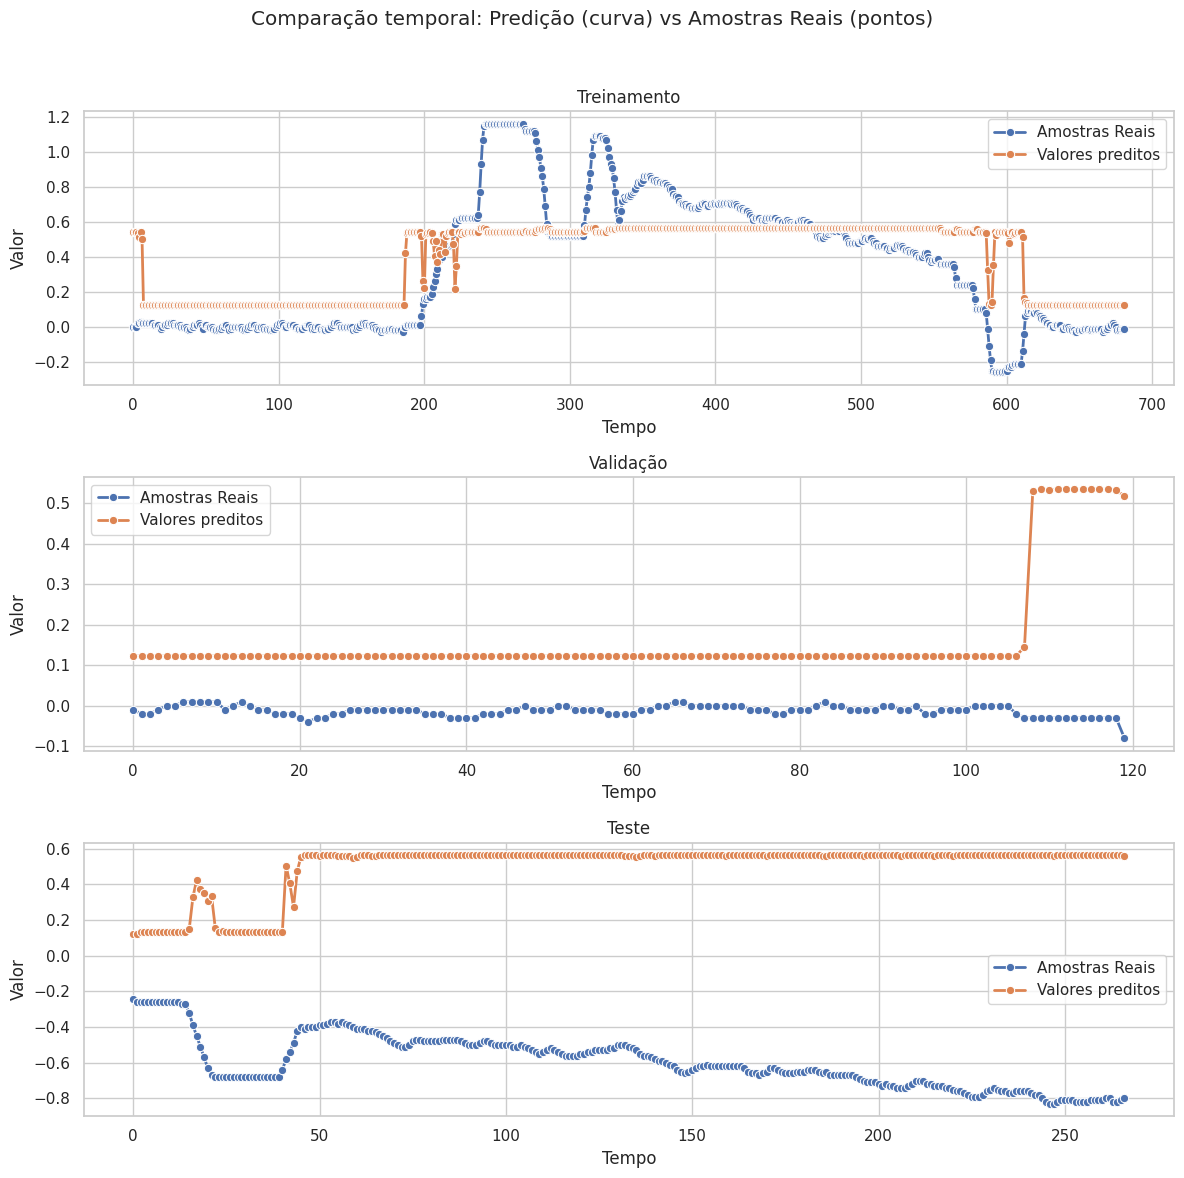

Testando combinacao3: Hidden Size=[2], regularizer=0.2, learning_rate=0.01
Shape X (batch, time_steps, features): (682, 2, 2)
Shape Y (batch, output_dim): (682, 1)
Shape h0 (batch, units): (682, 2)
Shape X (batch, time_steps, features): (120, 2, 2)
Shape Y (batch, output_dim): (120, 1)
Shape h0 (batch, units): (120, 2)
Shape X (batch, time_steps, features): (267, 2, 2)
Shape Y (batch, output_dim): (267, 1)
Shape h0 (batch, units): (267, 2)
+++++++++++ [3] | 1 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
+++++++++++ [3] | 2 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
+++++++++++ [3] | 3 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
+++++++++++ [3] | 4 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
4/4 ━━━━━━━━━━━━

,r2_training,mse_training,mape_training,rmse_training,r2_test,mse_test,mape_test,rmse_test,r2_val,mse_val,mape_val,rmse_val
model_2_1,0.501377,0.070982,6.426358e+13,0.266424,-56.801389,1.259199,1.879290,1.122140,-261.207306,0.046715,1.223655e+14,0.216136
model_1_0,0.503825,0.070633,6.597657e+13,0.265769,-33.961213,0.761627,1.456831,0.872713,-229.280094,0.041027,1.295043e+14,0.202550
model_2_0,0.504834,0.070490,5.046211e+13,0.265499,-59.235709,1.312230,1.973169,1.145526,-231.846950,0.041484,8.753646e+13,0.203676
model_1_1,0.507259,0.070145,6.358627e+13,0.264848,-31.759743,0.713668,1.409604,0.844789,-219.959117,0.039366,1.239616e+14,0.198409
model_1_9,0.509655,0.069804,5.692521e+13,0.264204,-30.144361,0.678477,1.371760,0.823697,-189.674343,0.033970,1.094929e+14,0.184311
model_1_2,0.509686,0.069799,6.184491e+13,0.264195,-31.650071,0.711279,1.406423,0.843374,-212.189589,0.037982,1.202101e+14,0.194889
model_1_8,0.510028,0.069750,5.732037e+13,0.264103,-30.295248,0.681764,1.375231,0.825690,-191.046459,0.034215,1.104049e+14,0.184973
model_1_7,0.510343,0.069706,5.776221e+13,0.264018,-30.493202,0.686077,1.379756,0.828298,-192.721926,0.034513,1.114215e+14,0.185778
model_1_3,0.510633,0.069664,6.063480e+13,0.263940,-31.359019,0.704939,1.399650,0.839606,-206.390172,0.036949,1.176123e+14,0.192220
model_1_6,0.510694,0.069656,5.832013e+13,0.263924,-30.656371,0.689631,1.383495,0.830441,-195.456905,0.035001,1.126227e+14,0.187085


DataFrame salvo em ./content/results/metrics_5


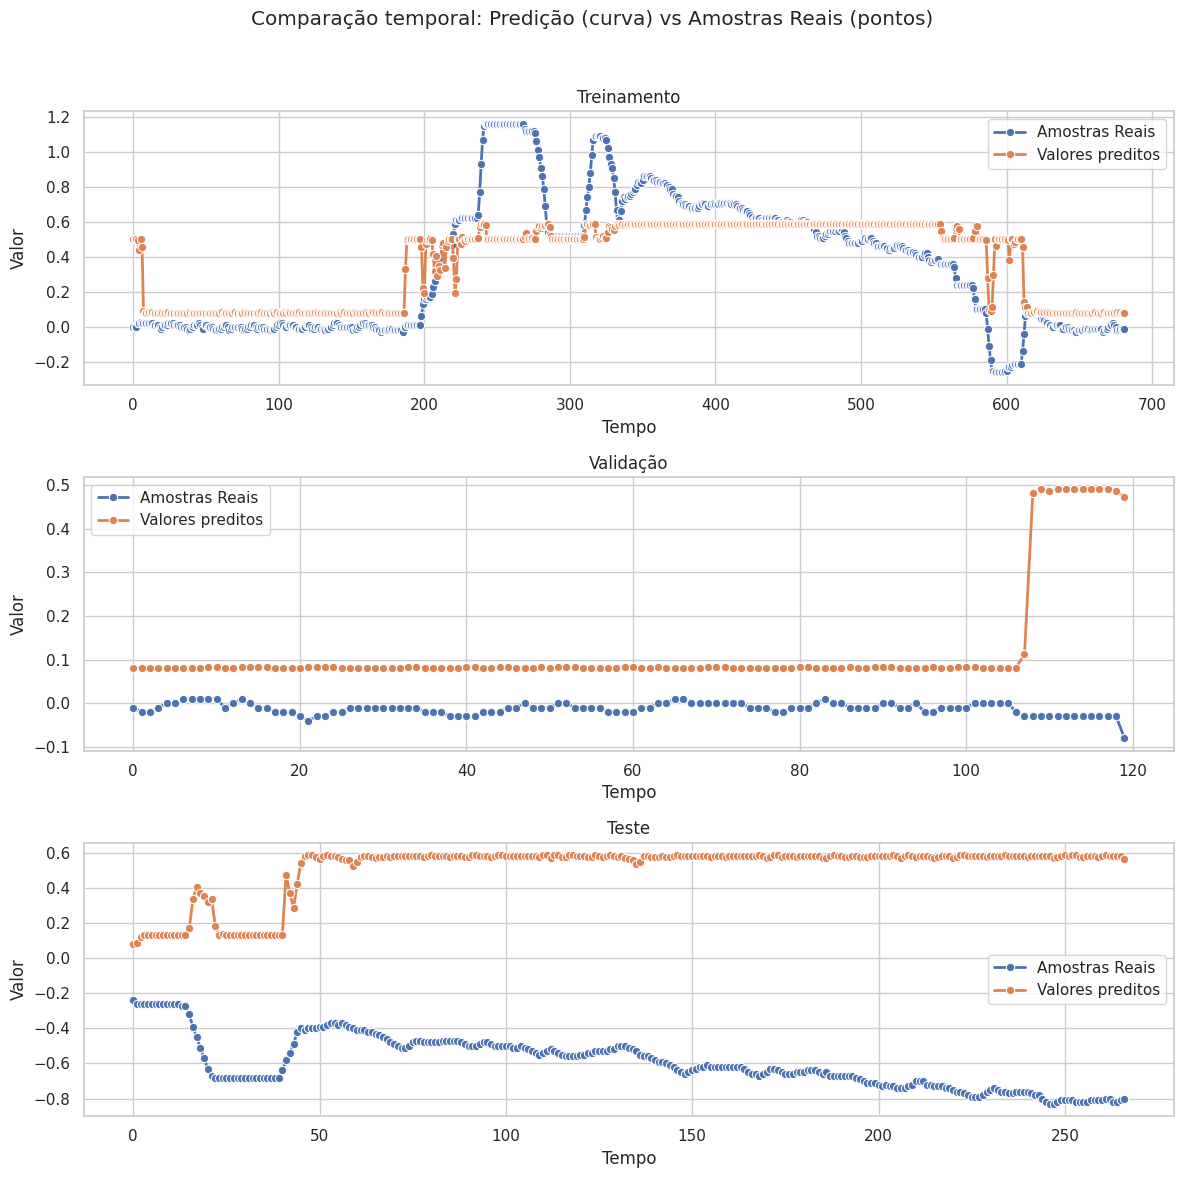

Testando combinacao6: Hidden Size=[5], regularizer=0.02, learning_rate=0.1
Shape X (batch, time_steps, features): (682, 2, 2)
Shape Y (batch, output_dim): (682, 1)
Shape h0 (batch, units): (682, 5)
Shape X (batch, time_steps, features): (120, 2, 2)
Shape Y (batch, output_dim): (120, 1)
Shape h0 (batch, units): (120, 5)
Shape X (batch, time_steps, features): (267, 2, 2)
Shape Y (batch, output_dim): (267, 1)
Shape h0 (batch, units): (267, 5)
+++++++++++ [6] | 1 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
+++++++++++ [6] | 2 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
+++++++++++ [6] | 3 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
+++++++++++ [6] | 4 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━

,r2_training,mse_training,mape_training,rmse_training,r2_test,mse_test,mape_test,rmse_test,r2_val,mse_val,mape_val,rmse_val
model_2_1,0.501377,0.070982,6.426358e+13,0.266424,-56.801389,1.259199,1.879290,1.122140,-261.207306,0.046715,1.223655e+14,0.216136
model_1_0,0.503825,0.070633,6.597657e+13,0.265769,-33.961213,0.761627,1.456831,0.872713,-229.280094,0.041027,1.295043e+14,0.202550
model_2_0,0.504834,0.070490,5.046211e+13,0.265499,-59.235709,1.312230,1.973169,1.145526,-231.846950,0.041484,8.753646e+13,0.203676
model_1_1,0.507259,0.070145,6.358627e+13,0.264848,-31.759743,0.713668,1.409604,0.844789,-219.959117,0.039366,1.239616e+14,0.198409
model_1_9,0.509655,0.069804,5.692521e+13,0.264204,-30.144361,0.678477,1.371760,0.823697,-189.674343,0.033970,1.094929e+14,0.184311
model_1_2,0.509686,0.069799,6.184491e+13,0.264195,-31.650071,0.711279,1.406423,0.843374,-212.189589,0.037982,1.202101e+14,0.194889
model_1_8,0.510028,0.069750,5.732037e+13,0.264103,-30.295248,0.681764,1.375231,0.825690,-191.046459,0.034215,1.104049e+14,0.184973
model_1_7,0.510343,0.069706,5.776221e+13,0.264018,-30.493202,0.686077,1.379756,0.828298,-192.721926,0.034513,1.114215e+14,0.185778
model_1_3,0.510633,0.069664,6.063480e+13,0.263940,-31.359019,0.704939,1.399650,0.839606,-206.390172,0.036949,1.176123e+14,0.192220
model_1_6,0.510694,0.069656,5.832013e+13,0.263924,-30.656371,0.689631,1.383495,0.830441,-195.456905,0.035001,1.126227e+14,0.187085


DataFrame salvo em ./content/results/metrics_9


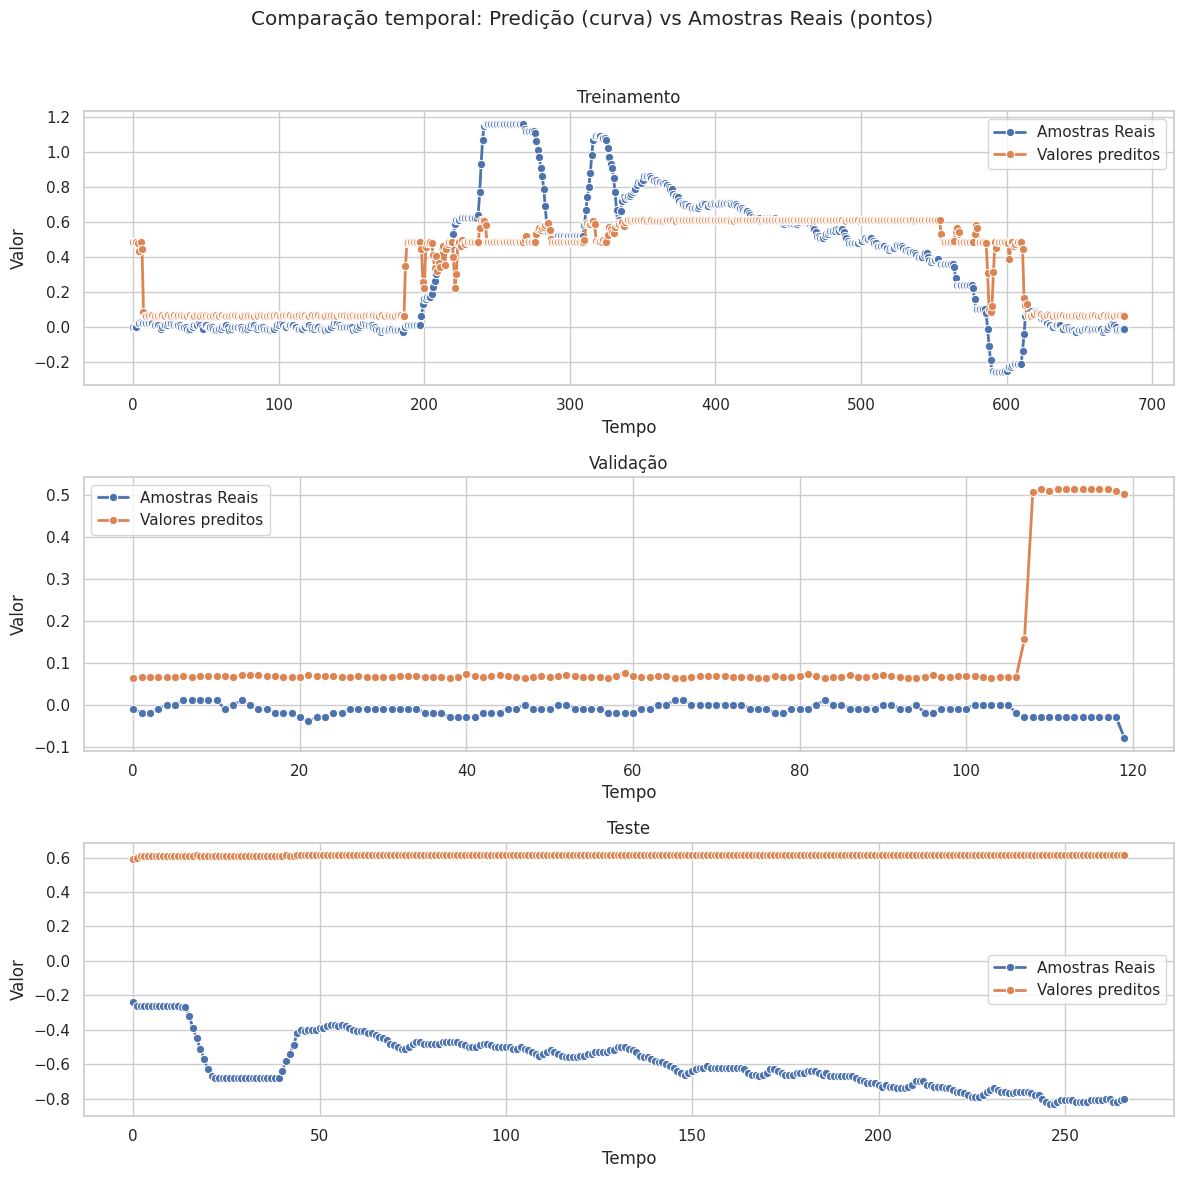

Testando combinacao10: Hidden Size=[10], regularizer=0.02, learning_rate=0.1
Shape X (batch, time_steps, features): (682, 2, 2)
Shape Y (batch, output_dim): (682, 1)
Shape h0 (batch, units): (682, 10)
Shape X (batch, time_steps, features): (120, 2, 2)
Shape Y (batch, output_dim): (120, 1)
Shape h0 (batch, units): (120, 10)
Shape X (batch, time_steps, features): (267, 2, 2)
Shape Y (batch, output_dim): (267, 1)
Shape h0 (batch, units): (267, 10)
+++++++++++ [10] | 1 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
+++++++++++ [10] | 2 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
+++++++++++ [10] | 3 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
+++++++++++ [10] | 4 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━

,r2_training,mse_training,mape_training,rmse_training,r2_test,mse_test,mape_test,rmse_test,r2_val,mse_val,mape_val,rmse_val
model_2_1,0.501377,0.070982,6.426358e+13,0.266424,-56.801389,1.259199,1.879290,1.122140,-261.207306,0.046715,1.223655e+14,0.216136
model_1_0,0.503825,0.070633,6.597657e+13,0.265769,-33.961213,0.761627,1.456831,0.872713,-229.280094,0.041027,1.295043e+14,0.202550
model_2_0,0.504834,0.070490,5.046211e+13,0.265499,-59.235709,1.312230,1.973169,1.145526,-231.846950,0.041484,8.753646e+13,0.203676
model_1_1,0.507259,0.070145,6.358627e+13,0.264848,-31.759743,0.713668,1.409604,0.844789,-219.959117,0.039366,1.239616e+14,0.198409
model_1_9,0.509655,0.069804,5.692521e+13,0.264204,-30.144361,0.678477,1.371760,0.823697,-189.674343,0.033970,1.094929e+14,0.184311
model_1_2,0.509686,0.069799,6.184491e+13,0.264195,-31.650071,0.711279,1.406423,0.843374,-212.189589,0.037982,1.202101e+14,0.194889
model_1_8,0.510028,0.069750,5.732037e+13,0.264103,-30.295248,0.681764,1.375231,0.825690,-191.046459,0.034215,1.104049e+14,0.184973
model_1_7,0.510343,0.069706,5.776221e+13,0.264018,-30.493202,0.686077,1.379756,0.828298,-192.721926,0.034513,1.114215e+14,0.185778
model_1_3,0.510633,0.069664,6.063480e+13,0.263940,-31.359019,0.704939,1.399650,0.839606,-206.390172,0.036949,1.176123e+14,0.192220
model_1_6,0.510694,0.069656,5.832013e+13,0.263924,-30.656371,0.689631,1.383495,0.830441,-195.456905,0.035001,1.126227e+14,0.187085


DataFrame salvo em ./content/results/metrics_13


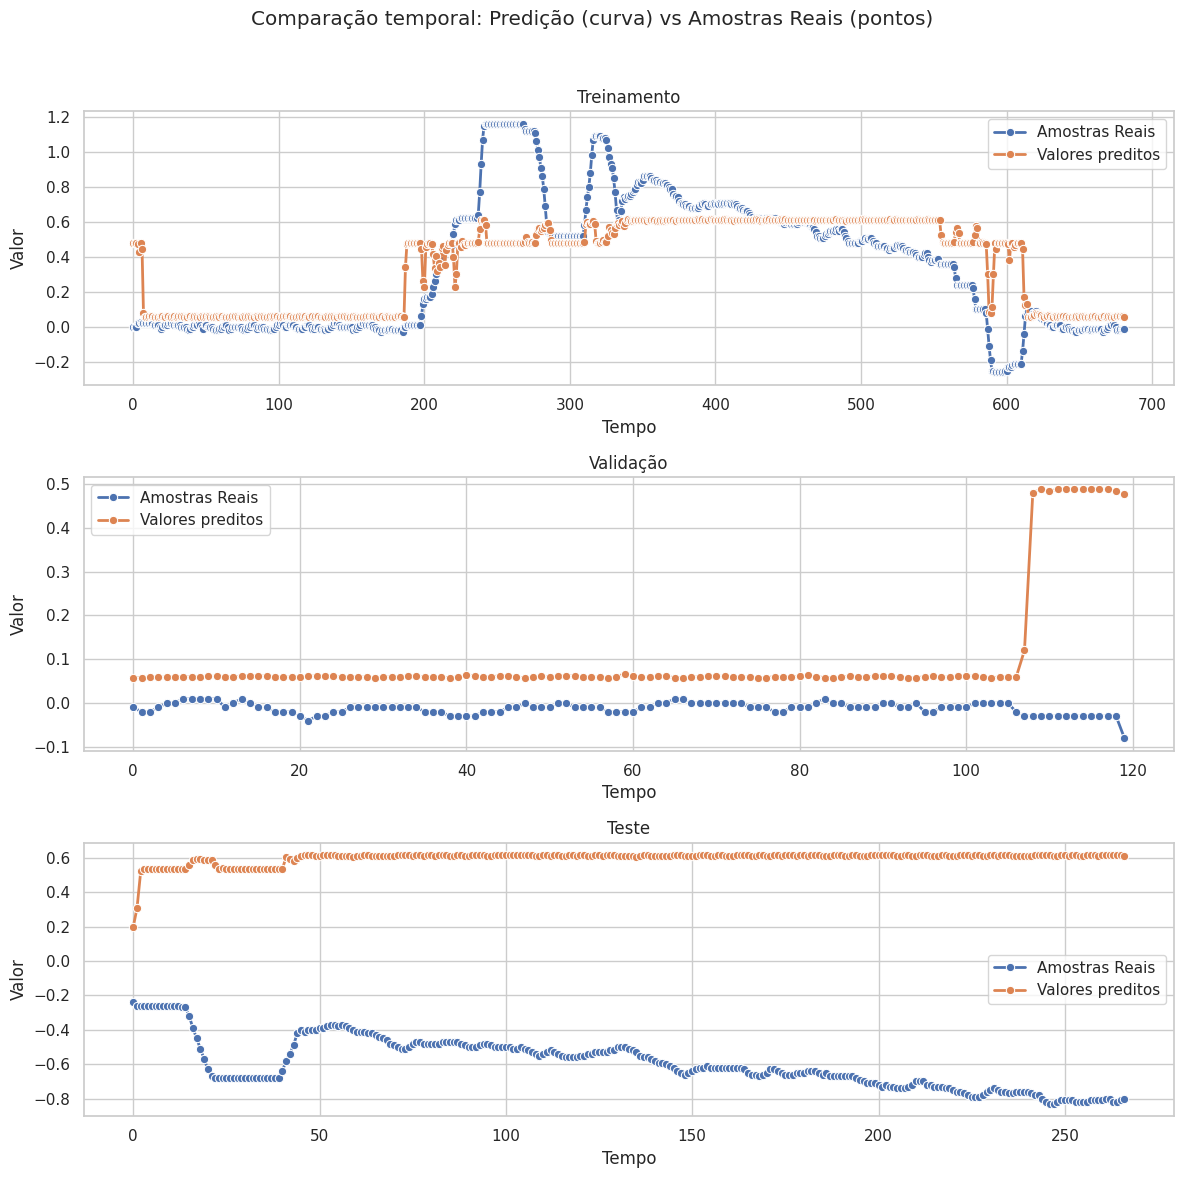

Testando combinacao14: Hidden Size=[15], regularizer=0.02, learning_rate=0.1
Shape X (batch, time_steps, features): (682, 2, 2)
Shape Y (batch, output_dim): (682, 1)
Shape h0 (batch, units): (682, 15)
Shape X (batch, time_steps, features): (120, 2, 2)
Shape Y (batch, output_dim): (120, 1)
Shape h0 (batch, units): (120, 15)
Shape X (batch, time_steps, features): (267, 2, 2)
Shape Y (batch, output_dim): (267, 1)
Shape h0 (batch, units): (267, 15)
+++++++++++ [14] | 1 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
+++++++++++ [14] | 2 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
+++++++++++ [14] | 3 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
+++++++++++ [14] | 4 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━

,r2_training,mse_training,mape_training,rmse_training,r2_test,mse_test,mape_test,rmse_test,r2_val,mse_val,mape_val,rmse_val
model_2_1,0.501377,0.070982,6.426358e+13,0.266424,-56.801389,1.259199,1.879290,1.122140,-261.207306,0.046715,1.223655e+14,0.216136
model_1_0,0.503825,0.070633,6.597657e+13,0.265769,-33.961213,0.761627,1.456831,0.872713,-229.280094,0.041027,1.295043e+14,0.202550
model_2_0,0.504834,0.070490,5.046211e+13,0.265499,-59.235709,1.312230,1.973169,1.145526,-231.846950,0.041484,8.753646e+13,0.203676
model_17_8,0.505786,0.070354,4.963355e+13,0.265244,-53.023599,1.176900,1.841438,1.084850,-178.099353,0.031908,9.199578e+13,0.178629
model_1_1,0.507259,0.070145,6.358627e+13,0.264848,-31.759743,0.713668,1.409604,0.844789,-219.959117,0.039366,1.239616e+14,0.198409
model_1_9,0.509655,0.069804,5.692521e+13,0.264204,-30.144361,0.678477,1.371760,0.823697,-189.674343,0.033970,1.094929e+14,0.184311
model_1_2,0.509686,0.069799,6.184491e+13,0.264195,-31.650071,0.711279,1.406423,0.843374,-212.189589,0.037982,1.202101e+14,0.194889
model_1_8,0.510028,0.069750,5.732037e+13,0.264103,-30.295248,0.681764,1.375231,0.825690,-191.046459,0.034215,1.104049e+14,0.184973
model_1_7,0.510343,0.069706,5.776221e+13,0.264018,-30.493202,0.686077,1.379756,0.828298,-192.721926,0.034513,1.114215e+14,0.185778
model_1_3,0.510633,0.069664,6.063480e+13,0.263940,-31.359019,0.704939,1.399650,0.839606,-206.390172,0.036949,1.176123e+14,0.192220


DataFrame salvo em ./content/results/metrics_17


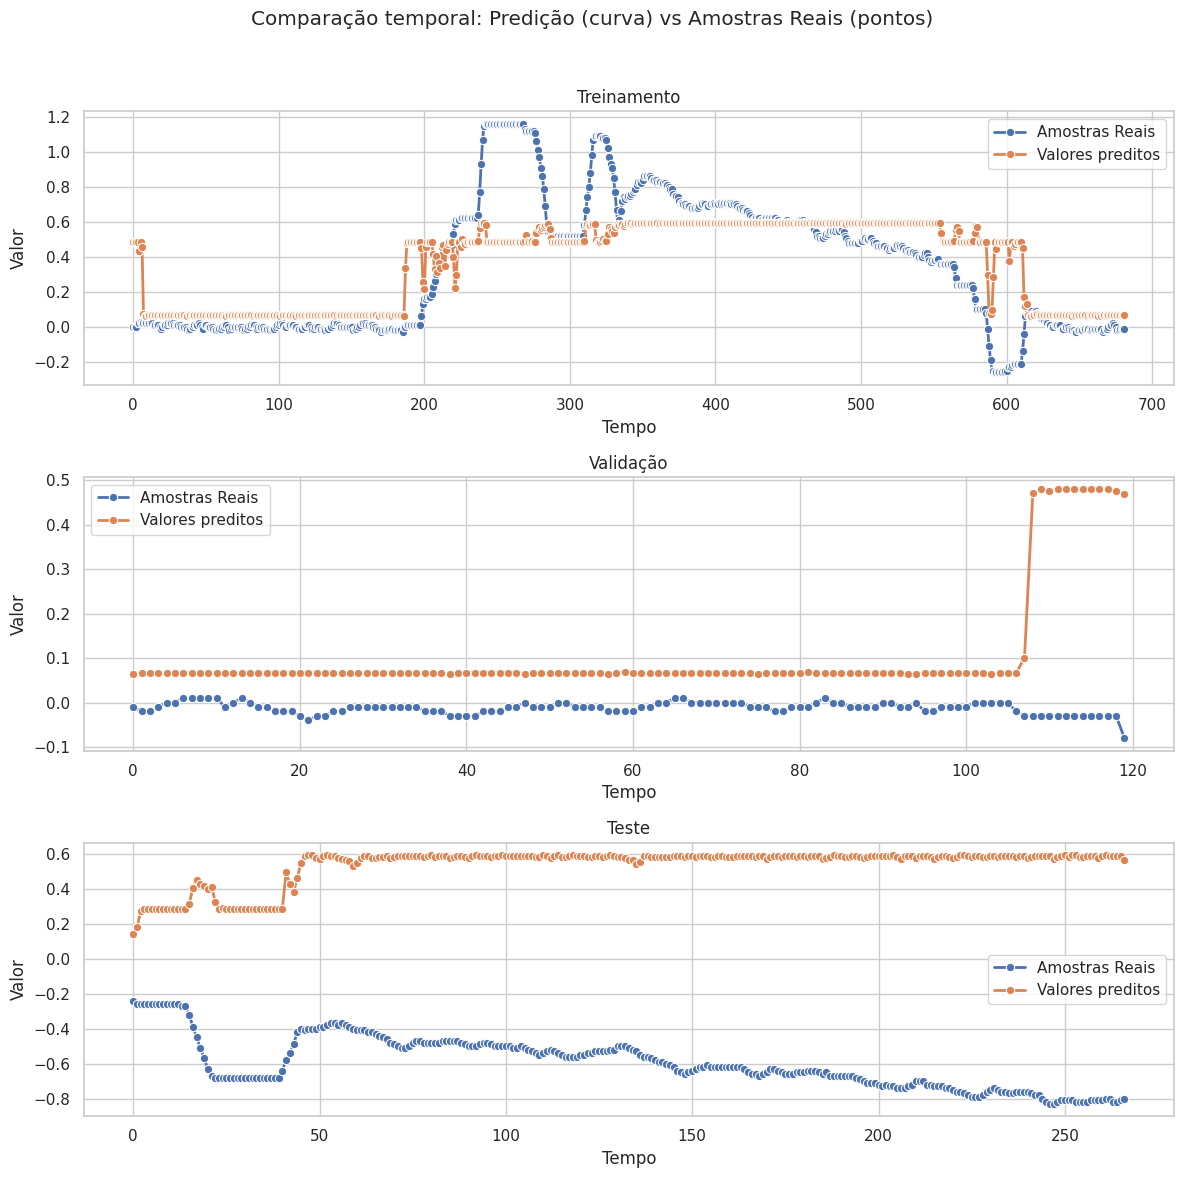

Testando combinacao18: Hidden Size=[20], regularizer=0.02, learning_rate=0.1
Shape X (batch, time_steps, features): (682, 2, 2)
Shape Y (batch, output_dim): (682, 1)
Shape h0 (batch, units): (682, 20)
Shape X (batch, time_steps, features): (120, 2, 2)
Shape Y (batch, output_dim): (120, 1)
Shape h0 (batch, units): (120, 20)
Shape X (batch, time_steps, features): (267, 2, 2)
Shape Y (batch, output_dim): (267, 1)
Shape h0 (batch, units): (267, 20)
+++++++++++ [18] | 1 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
+++++++++++ [18] | 2 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
+++++++++++ [18] | 3 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
+++++++++++ [18] | 4 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━

,r2_training,mse_training,mape_training,rmse_training,r2_test,mse_test,mape_test,rmse_test,r2_val,mse_val,mape_val,rmse_val
model_2_1,0.501377,0.070982,6.426358e+13,0.266424,-56.801389,1.259199,1.879290,1.122140,-261.207306,0.046715,1.223655e+14,0.216136
model_1_0,0.503825,0.070633,6.597657e+13,0.265769,-33.961213,0.761627,1.456831,0.872713,-229.280094,0.041027,1.295043e+14,0.202550
model_2_0,0.504834,0.070490,5.046211e+13,0.265499,-59.235709,1.312230,1.973169,1.145526,-231.846950,0.041484,8.753646e+13,0.203676
model_17_8,0.505786,0.070354,4.963355e+13,0.265244,-53.023599,1.176900,1.841438,1.084850,-178.099353,0.031908,9.199578e+13,0.178629
model_1_1,0.507259,0.070145,6.358627e+13,0.264848,-31.759743,0.713668,1.409604,0.844789,-219.959117,0.039366,1.239616e+14,0.198409
...,...,...,...,...,...,...,...,...,...,...,...,...
model_13_9,0.541219,0.065310,3.704898e+13,0.255559,-65.729035,1.453687,2.083752,1.205689,-176.212769,0.031572,6.078100e+13,0.177686
model_17_4,0.541680,0.065245,3.943303e+13,0.255430,-61.678201,1.365439,1.989506,1.168520,-180.835423,0.032396,6.548924e+13,0.179988
model_17_5,0.541801,0.065227,3.980249e+13,0.255396,-61.395538,1.359282,1.980863,1.165882,-180.444145,0.032326,6.668792e+13,0.179794
model_21_5,0.542204,0.065170,3.378414e+13,0.255284,-60.129213,1.331695,1.960107,1.153991,-163.432182,0.029295,5.221329e+13,0.171158


DataFrame salvo em ./content/results/metrics_21


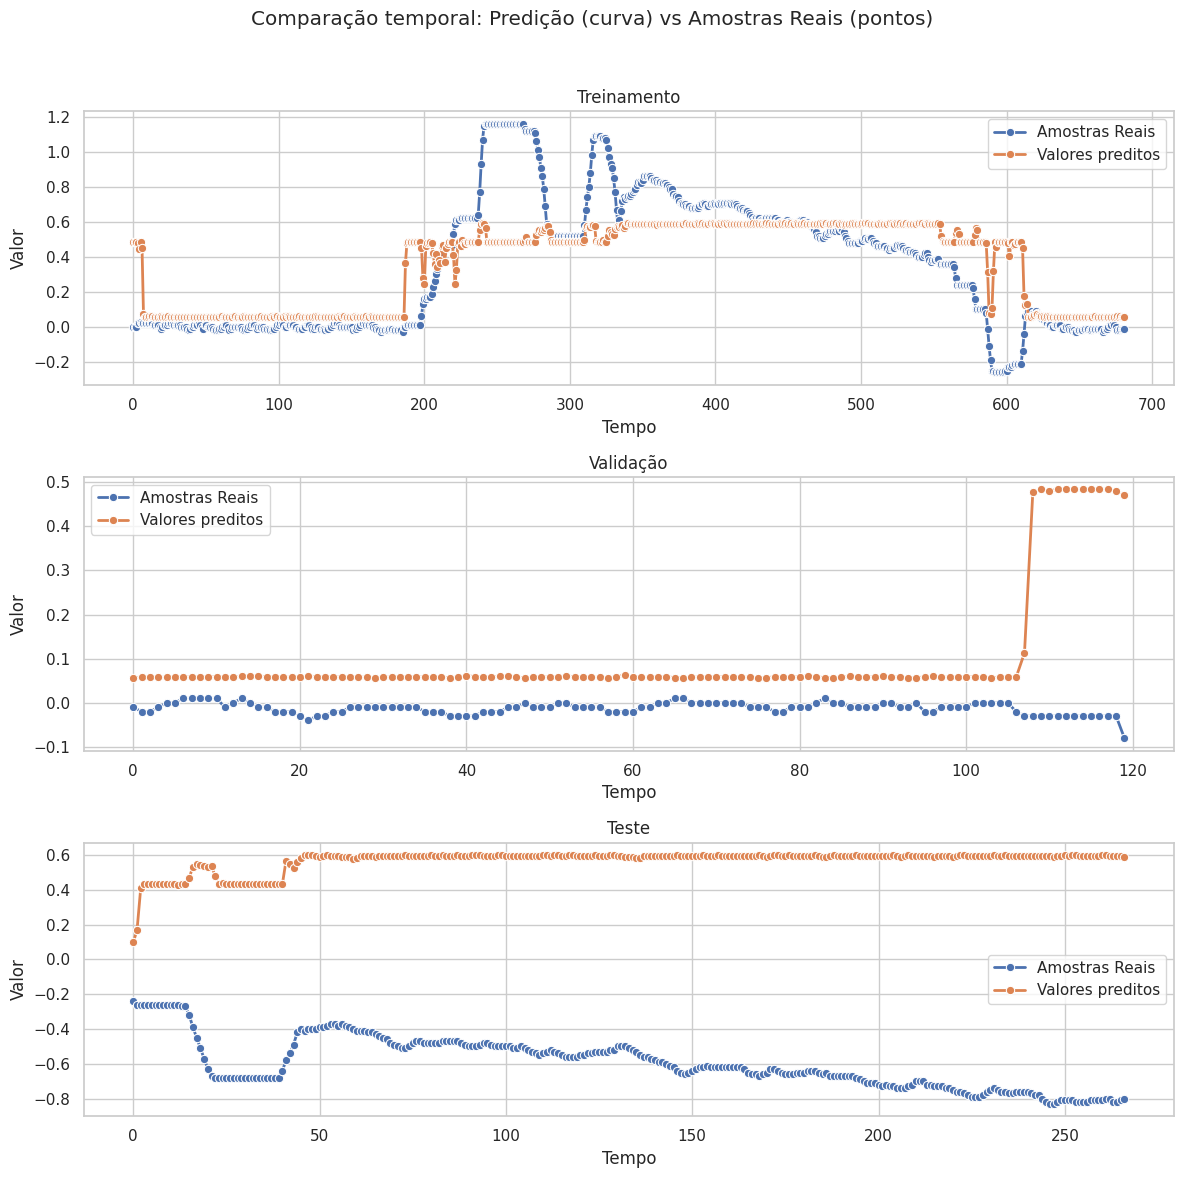

Testando combinacao22: Hidden Size=[30], regularizer=0.02, learning_rate=0.1
Shape X (batch, time_steps, features): (682, 2, 2)
Shape Y (batch, output_dim): (682, 1)
Shape h0 (batch, units): (682, 30)
Shape X (batch, time_steps, features): (120, 2, 2)
Shape Y (batch, output_dim): (120, 1)
Shape h0 (batch, units): (120, 30)
Shape X (batch, time_steps, features): (267, 2, 2)
Shape Y (batch, output_dim): (267, 1)
Shape h0 (batch, units): (267, 30)
+++++++++++ [22] | 1 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
+++++++++++ [22] | 2 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
+++++++++++ [22] | 3 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
+++++++++++ [22] | 4 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━

,r2_training,mse_training,mape_training,rmse_training,r2_test,mse_test,mape_test,rmse_test,r2_val,mse_val,mape_val,rmse_val
model_23_1,0.500112,0.071162,5.584417e+13,0.266762,-23.893103,0.542294,1.227871,0.736406,-162.844056,0.029190,1.085946e+14,0.170852
model_23_4,0.500253,0.071142,5.690173e+13,0.266724,-23.199698,0.527188,1.210570,0.726077,-167.071256,0.029944,1.096206e+14,0.173042
model_23_2,0.500310,0.071134,5.683596e+13,0.266709,-23.074559,0.524462,1.207402,0.724198,-166.050499,0.029762,1.093108e+14,0.172516
model_23_3,0.500639,0.071087,5.724679e+13,0.266621,-22.918132,0.521055,1.203524,0.721841,-167.512034,0.030022,1.101452e+14,0.173269
model_2_1,0.501377,0.070982,6.426358e+13,0.266424,-56.801389,1.259199,1.879290,1.122140,-261.207306,0.046715,1.223655e+14,0.216136
...,...,...,...,...,...,...,...,...,...,...,...,...
model_13_9,0.541219,0.065310,3.704898e+13,0.255559,-65.729035,1.453687,2.083752,1.205689,-176.212769,0.031572,6.078100e+13,0.177686
model_17_4,0.541680,0.065245,3.943303e+13,0.255430,-61.678201,1.365439,1.989506,1.168520,-180.835423,0.032396,6.548924e+13,0.179988
model_17_5,0.541801,0.065227,3.980249e+13,0.255396,-61.395538,1.359282,1.980863,1.165882,-180.444145,0.032326,6.668792e+13,0.179794
model_21_5,0.542204,0.065170,3.378414e+13,0.255284,-60.129213,1.331695,1.960107,1.153991,-163.432182,0.029295,5.221329e+13,0.171158


DataFrame salvo em ./content/results/metrics_23


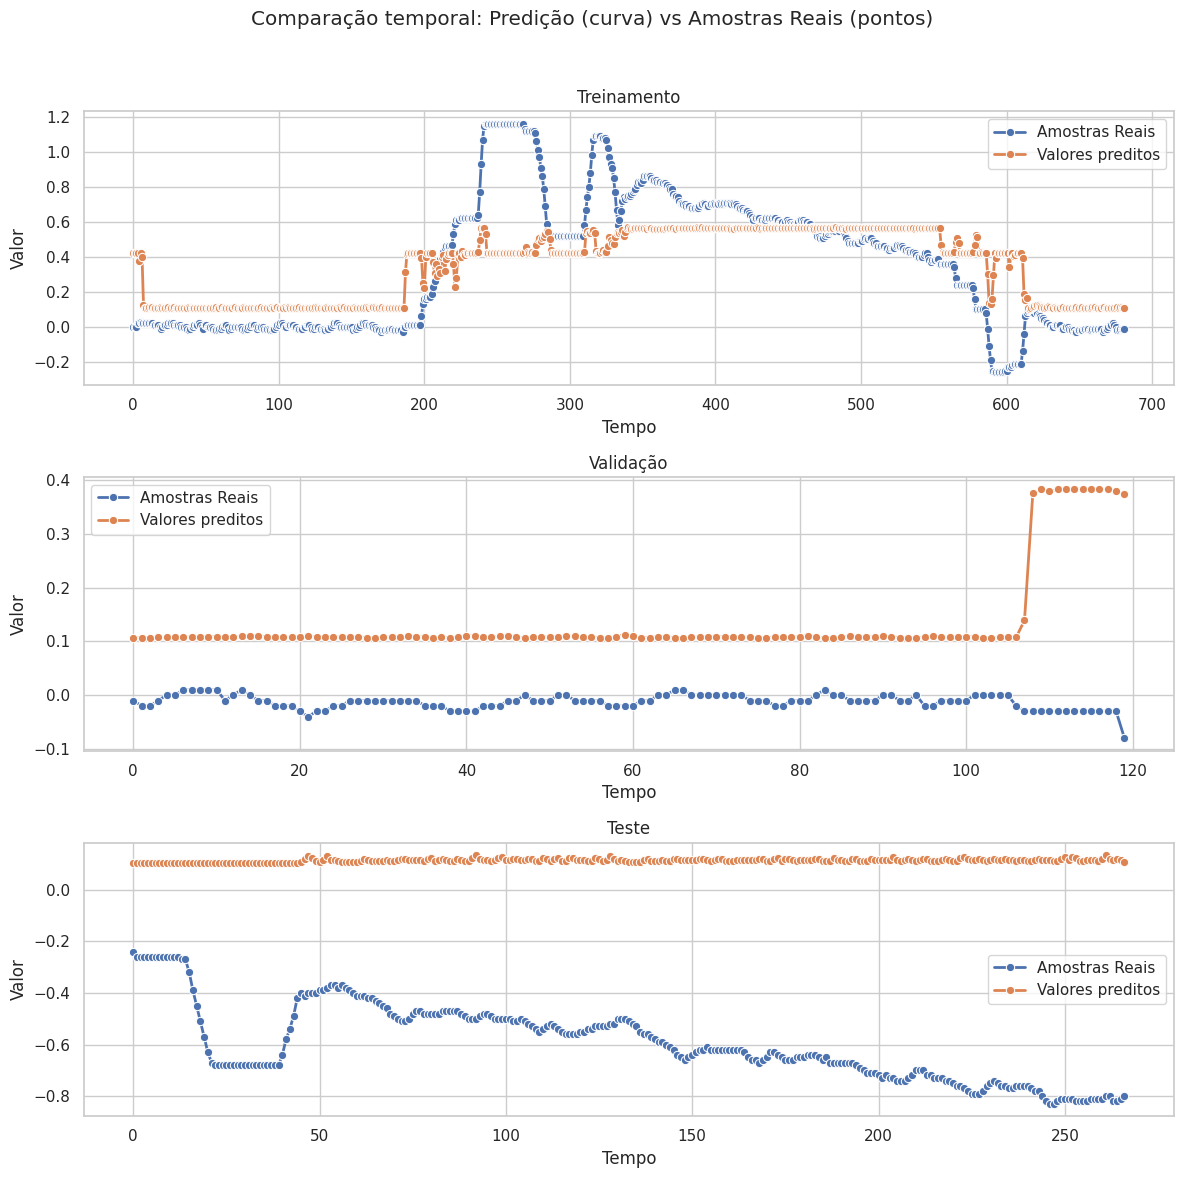

Testando combinacao24: Hidden Size=[30], regularizer=0.2, learning_rate=0.1
Shape X (batch, time_steps, features): (682, 2, 2)
Shape Y (batch, output_dim): (682, 1)
Shape h0 (batch, units): (682, 30)
Shape X (batch, time_steps, features): (120, 2, 2)
Shape Y (batch, output_dim): (120, 1)
Shape h0 (batch, units): (120, 30)
Shape X (batch, time_steps, features): (267, 2, 2)
Shape Y (batch, output_dim): (267, 1)
Shape h0 (batch, units): (267, 30)
+++++++++++ [24] | 1 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
+++++++++++ [24] | 2 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
+++++++++++ [24] | 3 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
+++++++++++ [24] | 4 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━

In [ ]:
Valuer.Evaluate(hidden_sizes = [[2], [5], [10], [15], [20], [30], [25],
                                [2, 5], [2, 10], [5, 5], [5, 10]],
            regularizers=[0.02, 0.2],
            learning_rate=[0.01, 0.1],
            run_times = 10, 
            boundarie = 0.5,
            sort_by = 'r2_training',
) 